In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


In [2]:
# -------------------------------
# PATHS
# -------------------------------
train_dir = r"D:\Chilli final dataset\augtrain"
val_dir   = r"D:\Chilli final dataset\val"
test_dir = r"D:\Chilli final dataset\test"

IMG_SIZE = 224
BATCH_SIZE = 32

# MixUp / CutMix parameters
MIXUP_ALPHA = 0.2
CUTMIX_ALPHA = 1.0
MIX_PROB = 0.5   # 50% MixUp, 50% CutMix

# -------------------------------
# 🔥 DATA AUGMENTATION
# -------------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    brightness_range=[0.7, 1.3],
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_gen_base = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_datagen = ImageDataGenerator(rescale=1./255)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False   # IMPORTANT for metrics
)

num_classes = train_gen_base.num_classes



Found 24000 images belonging to 3 classes.
Found 2207 images belonging to 3 classes.
Found 2207 images belonging to 3 classes.


In [3]:
# -------------------------------
# 🔥 MIXUP FUNCTION
# -------------------------------
def mixup(x1, y1, x2, y2, alpha=0.2):
    lam = np.random.beta(alpha, alpha)
    x = lam * x1 + (1 - lam) * x2
    y = lam * y1 + (1 - lam) * y2
    return x, y

# -------------------------------
# 🔥 CUTMIX FUNCTION
# -------------------------------
def cutmix(x1, y1, x2, y2, alpha=1.0):
    lam = np.random.beta(alpha, alpha)

    batch_size, h, w, c = x1.shape

    # Random box
    cx = np.random.randint(w)
    cy = np.random.randint(h)

    cut_w = int(w * np.sqrt(1 - lam))
    cut_h = int(h * np.sqrt(1 - lam))

    x1_copy = np.copy(x1)

    x1_copy[:, 
            max(cy - cut_h // 2, 0):min(cy + cut_h // 2, h),
            max(cx - cut_w // 2, 0):min(cx + cut_w // 2, w), :] = \
    x2[:, 
        max(cy - cut_h // 2, 0):min(cy + cut_h // 2, h),
        max(cx - cut_w // 2, 0):min(cx + cut_w // 2, w), :]

    lam_adjusted = 1 - (cut_w * cut_h) / (w * h)
    y = lam_adjusted * y1 + (1 - lam_adjusted) * y2

    return x1_copy, y

# -------------------------------
# 🔥 COMBINED GENERATOR
# -------------------------------
def mix_generator(generator):
    while True:
        x1, y1 = next(generator)
        x2, y2 = next(generator)

        if np.random.rand() < MIX_PROB:
            x, y = mixup(x1, y1, x2, y2, MIXUP_ALPHA)
        else:
            x, y = cutmix(x1, y1, x2, y2, CUTMIX_ALPHA)

        yield x, y

train_gen = mix_generator(train_gen_base)


In [4]:
from tensorflow.keras import layers, models
import tensorflow as tf

def build_hybrid_attention_model(input_shape=(224,224,3), num_classes=3):

    inputs = layers.Input(shape=input_shape)

    # -------------------------------
    # 🔷 CNN FEATURE EXTRACTION
    # -------------------------------
    x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)

    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)

    x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)

    # Output shape: (batch, 28, 28, 128)

    # -------------------------------
    # 🔷 CONVERT TO SEQUENCE (ROW-WISE)
    # -------------------------------
    x = layers.Reshape((28, 28*128))(x)   # (batch, 28 timesteps, 3584 features)

    # -------------------------------
    # 🔷 BiLSTM LAYER
    # -------------------------------
    x = layers.Bidirectional(
        layers.LSTM(64, return_sequences=True)
    )(x)

    # -------------------------------
    # 🔥 ATTENTION MECHANISM
    # -------------------------------
    attention = layers.Attention()([x, x])   # Self-attention

    # Combine LSTM output + attention
    x = layers.Concatenate()([x, attention])

    # Reduce sequence to vector
    x = layers.GlobalAveragePooling1D()(x)

    # -------------------------------
    # 🔷 DNN CLASSIFIER
    # -------------------------------
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(64, activation='relu')(x)

    # -------------------------------
    # 🔷 OUTPUT LAYER
    # -------------------------------
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)

    return model

In [5]:
model = build_hybrid_attention_model(num_classes=num_classes)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 224, 224, 32)      │             896 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 224, 224, 32)      │             128 │ conv2d[0][0]               │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d (MaxPooling2D)  │ (None, 112, 112, 32)      │               0 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 112, 112, 64)      │          18,496 │ max_pooling2d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 112, 112, 64)      │             256 │ conv2d_1[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_1               │ (None, 56, 56, 64)        │               0 │ batch_normalization_1[0][… │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 56, 56, 128)       │          73,856 │ max_pooling2d_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 56, 56, 128)       │             512 │ conv2d_2[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_2               │ (None, 28, 28, 128)       │               0 │ batch_normalization_2[0][… │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ reshape (Reshape)             │ (None, 28, 3584)          │               0 │ max_pooling2d_2[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bidirectional (Bidirectional) │ (None, 28, 128)           │       1,868,288 │ reshape[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ attention (Attention)         │ (None, 28, 128)           │               0 │ bidirectional[0][0],       │
│                               │                           │                 │ bidirectional[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 28, 256)           │               0 │ bidirectional[0][0],       │
│                               │                           │               

 Total params: 2,069,571 (7.89 MB)

 Trainable params: 2,069,123 (7.89 MB)

 Non-trainable params: 448 (1.75 KB)

In [6]:
# -------------------------------
# CALLBACKS
# -------------------------------
callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-6),
    ModelCheckpoint("Hybridcnnchilli_best_model.h5", monitor='val_accuracy', save_best_only=True)
]

steps_per_epoch = train_gen_base.samples // BATCH_SIZE

# -------------------------------
# 🚀 PHASE 1 TRAINING
# -------------------------------
history1 = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen,
    epochs=25,
    callbacks=callbacks
)

Epoch 1/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6883 - loss: 0.7903

C:\Users\amirtha\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


750/750 ━━━━━━━━━━━━━━━━━━━━ 1625s 2s/step - accuracy: 0.6883 - loss: 0.7901 - val_accuracy: 0.5664 - val_loss: 1.1997 - learning_rate: 1.0000e-04
Epoch 2/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 1575s 2s/step - accuracy: 0.8212 - loss: 0.5756 - val_accuracy: 0.4880 - val_loss: 1.4206 - learning_rate: 1.0000e-04
Epoch 3/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 1515s 2s/step - accuracy: 0.8417 - loss: 0.5367 - val_accuracy: 0.4685 - val_loss: 1.5110 - learning_rate: 1.0000e-04
Epoch 4/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 1510s 2s/step - accuracy: 0.8624 - loss: 0.5038 - val_accuracy: 0.4504 - val_loss: 1.5286 - learning_rate: 1.0000e-04
Epoch 5/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 1514s 2s/step - accuracy: 0.8680 - loss: 0.4796 - val_accuracy: 0.4413 - val_loss: 1.6083 - learning_rate: 3.0000e-05
Epoch 6/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 1503s 2s/step - accuracy: 0.8669 - loss: 0.4691 - val_accuracy: 0.4522 - val_loss: 1.6369 - learning_rate: 3.0000e-05
Epoch 7/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 1492s 2s/step - accurac

In [7]:
# -------------------------------
# 📊 FINAL RESULT (VAL + TEST)
# -------------------------------
val_loss, val_acc = model.evaluate(val_gen)
print(f"\n✅ Final Validation Accuracy: {val_acc * 100:.2f}%")

test_loss, test_acc = model.evaluate(test_gen)
print(f"✅ Final Test Accuracy: {test_acc * 100:.2f}%")

69/69 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.5534 - loss: 1.2431

✅ Final Validation Accuracy: 56.64%
69/69 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step - accuracy: 0.8050 - loss: 0.6257
✅ Final Test Accuracy: 53.83%


In [8]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Predictions
y_pred = model.predict(test_gen)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_gen.classes

# Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=test_gen.class_indices.keys()))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
print("\nConfusion Matrix:\n", cm)

69/69 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step

Classification Report:

                            precision    recall  f1-score   support

           Healthy control       0.56      0.99      0.72      1000
Initial Symptoms of ChiLCV       0.00      0.00      0.00       855
 Severe Symptoms of ChiLCV       0.46      0.56      0.51       352

                  accuracy                           0.54      2207
                 macro avg       0.34      0.52      0.41      2207
              weighted avg       0.33      0.54      0.40      2207


Confusion Matrix:
 [[991   0   9]
 [633   0 222]
 [145  10 197]]


69/69 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step

Classification Report:

                            precision    recall  f1-score   support

           Healthy control       0.56      0.99      0.72      1000
Initial Symptoms of ChiLCV       0.00      0.00      0.00       855
 Severe Symptoms of ChiLCV       0.46      0.56      0.51       352

                  accuracy                           0.54      2207
                 macro avg       0.34      0.52      0.41      2207
              weighted avg       0.33      0.54      0.40      2207


Confusion Matrix:
 [[991   0   9]
 [633   0 222]
 [145  10 197]]


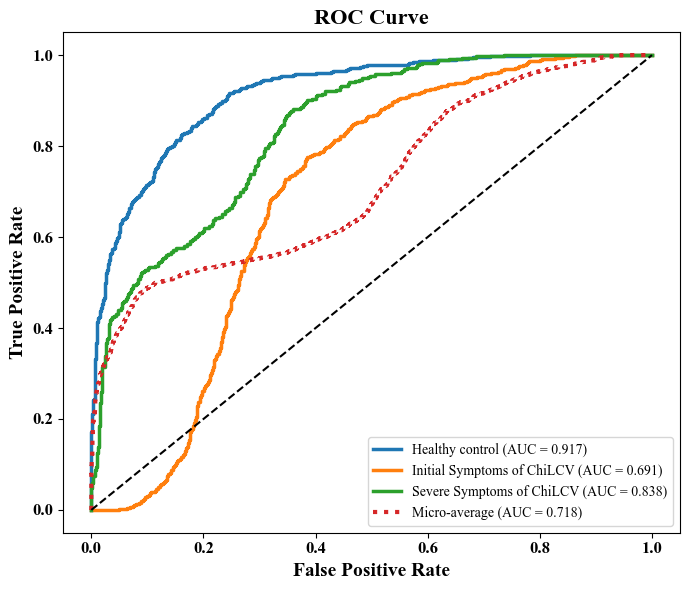

In [9]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Predictions
# -------------------------------
y_pred = model.predict(test_gen)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_gen.classes

class_names = list(test_gen.class_indices.keys())
num_classes = len(class_names)

# -------------------------------
# Classification Report
# -------------------------------
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

# -------------------------------
# Confusion Matrix
# -------------------------------
cm = confusion_matrix(y_true, y_pred_classes)
print("\nConfusion Matrix:\n", cm)

# -------------------------------
# 🔥 ROC Curve
# -------------------------------
plt.rcParams['font.family'] = 'Times New Roman'

# Binarize labels
y_true_bin = label_binarize(y_true, classes=range(num_classes))

plt.figure(figsize=(7,6))

# ROC per class
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, linewidth=2.5,
             label=f'{class_names[i]} (AUC = {roc_auc:.3f})')

# 🔥 Micro-average ROC (important)
fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_pred.ravel())
auc_micro = auc(fpr_micro, tpr_micro)

plt.plot(fpr_micro, tpr_micro,
         linestyle=':',
         linewidth=3,
         label=f'Micro-average (AUC = {auc_micro:.3f})')

# Diagonal line
plt.plot([0,1], [0,1], 'k--', linewidth=1.5)

# Labels
plt.title('ROC Curve', fontsize=16, fontweight='bold')
plt.xlabel('False Positive Rate', fontsize=14, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=14, fontweight='bold')

plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

plt.legend(fontsize=10)

plt.tight_layout()
plt.savefig("Fig_ROC_Q1.tiff", dpi=300)
plt.show()

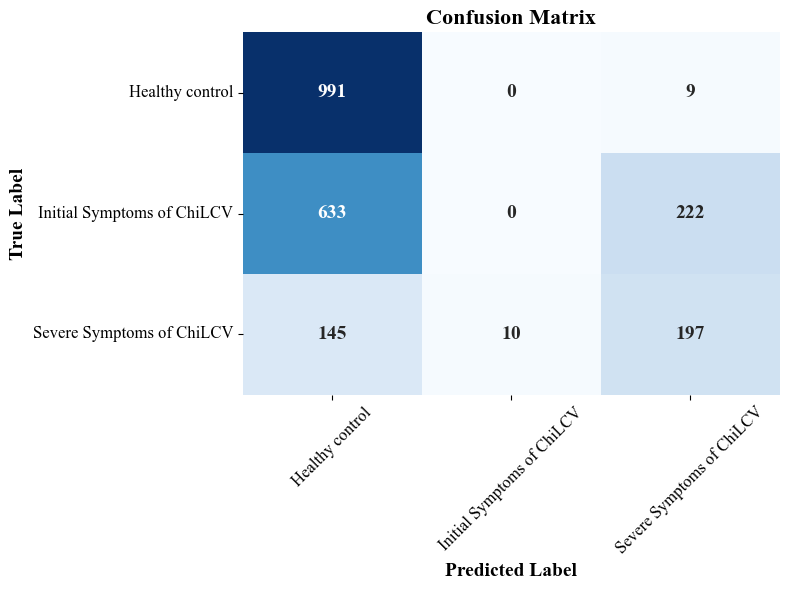

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.rcParams['font.family'] = 'Times New Roman'

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar=False,
            annot_kws={"size":14, "weight":"bold"})  # 🔥 bigger & bold

plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=14, fontweight='bold')

plt.xticks(rotation=45, fontsize=12)
plt.yticks(rotation=0, fontsize=12)

plt.tight_layout()
plt.savefig("confusion_matrix_heatmap.tiff", dpi=300)
plt.show()

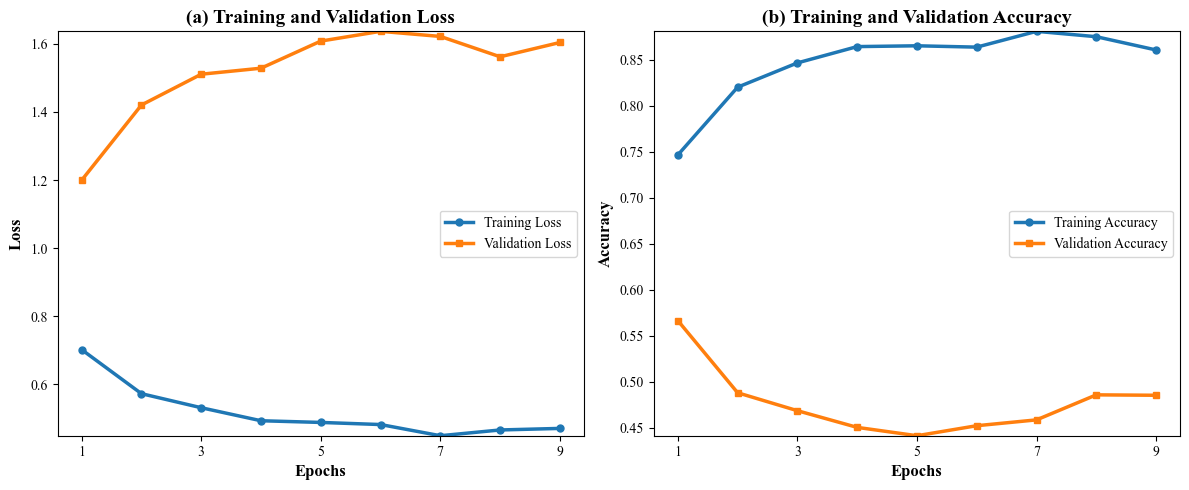

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Set Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'

# Extract data
train_loss = history1.history['loss']
val_loss = history1.history['val_loss']
train_acc = history1.history['accuracy']
val_acc = history1.history['val_accuracy']

epochs = range(1, len(train_loss) + 1)

# -------------------------------
# Set consistent limits
# -------------------------------
loss_min = min(min(train_loss), min(val_loss))
loss_max = max(max(train_loss), max(val_loss))

acc_min = min(min(train_acc), min(val_acc))
acc_max = max(max(train_acc), max(val_acc))

# -------------------------------
# Create subplots
# -------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Common x-ticks (every 2 epochs)
xticks = np.arange(1, len(epochs)+1, 2)

# -------------------------------
# (a) Loss Plot
# -------------------------------
axes[0].plot(epochs, train_loss, marker='o', markersize=5, linewidth=2.5)
axes[0].plot(epochs, val_loss, marker='s', markersize=5, linewidth=2.5)

axes[0].set_title('(a) Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epochs', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Loss', fontsize=12, fontweight='bold')

axes[0].set_xticks(xticks)
axes[0].set_ylim([loss_min, loss_max])

axes[0].legend(['Training Loss', 'Validation Loss'], fontsize=10)
axes[0].grid(False)

# -------------------------------
# (b) Accuracy Plot
# -------------------------------
axes[1].plot(epochs, train_acc, marker='o', markersize=5, linewidth=2.5)
axes[1].plot(epochs, val_acc, marker='s', markersize=5, linewidth=2.5)

axes[1].set_title('(b) Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epochs', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Accuracy', fontsize=12, fontweight='bold')

axes[1].set_xticks(xticks)
axes[1].set_ylim([acc_min, acc_max])

axes[1].legend(['Training Accuracy', 'Validation Accuracy'], fontsize=10)
axes[1].grid(False)

# Layout
plt.tight_layout()

# Save
plt.savefig("Fig5_final_Q1.tiff", dpi=300)

plt.show()

In [12]:
class_names = [
    "Healthy control",
    "Initial Symptoms of ChiLCV",
    "Severe Symptoms of ChiLCV"
]
print(train_gen_base.class_indices)
class_names = list(train_gen_base.class_indices.keys())

{'Healthy control': 0, 'Initial Symptoms of ChiLCV': 1, 'Severe Symptoms of ChiLCV': 2}


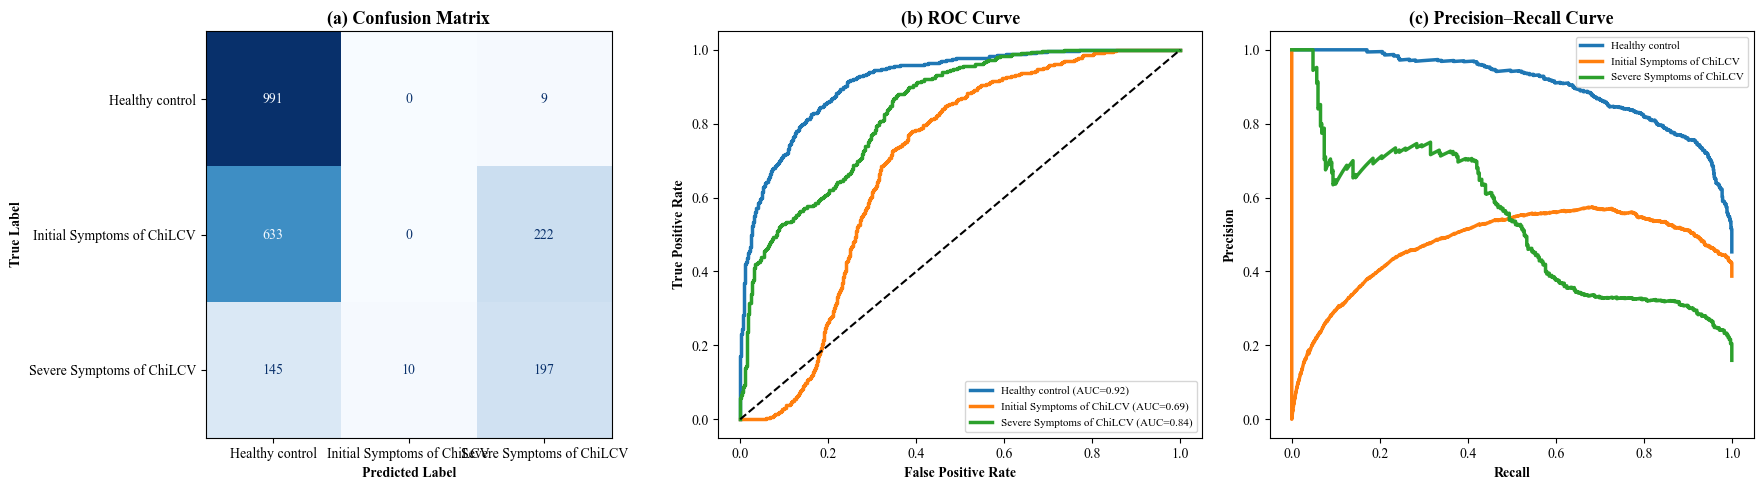

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize

# Set Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'

# -------------------------------
# Predictions (already computed)
# -------------------------------
# y_pred = model.predict(test_gen)
# y_pred_classes = np.argmax(y_pred, axis=1)
# y_true = test_gen.classes

class_names = list(test_gen.class_indices.keys())
num_classes = len(class_names)

# Binarize labels
y_true_bin = label_binarize(y_true, classes=range(num_classes))

# -------------------------------
# Create figure
# -------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# ===============================
# (a) Confusion Matrix
# ===============================
cm = confusion_matrix(y_true, y_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)

axes[0].set_title('(a) Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontweight='bold')
axes[0].set_ylabel('True Label', fontweight='bold')

# ===============================
# (b) ROC Curve
# ===============================
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    
    axes[1].plot(fpr, tpr, linewidth=2.5,
                 label=f'{class_names[i]} (AUC={roc_auc:.2f})')

axes[1].plot([0,1], [0,1], 'k--', linewidth=1.5)
axes[1].set_title('(b) ROC Curve', fontsize=13, fontweight='bold')
axes[1].set_xlabel('False Positive Rate', fontweight='bold')
axes[1].set_ylabel('True Positive Rate', fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].grid(False)

# ===============================
# (c) Precision-Recall Curve
# ===============================
for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_pred[:, i])
    
    axes[2].plot(recall, precision, linewidth=2.5,
                 label=class_names[i])

axes[2].set_title('(c) Precision–Recall Curve', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Recall', fontweight='bold')
axes[2].set_ylabel('Precision', fontweight='bold')
axes[2].legend(fontsize=8)
axes[2].grid(False)

# -------------------------------
# Final layout
# -------------------------------
plt.tight_layout()
plt.savefig("Fig_Combined_Performance_Q1.tiff", dpi=300)
plt.show()

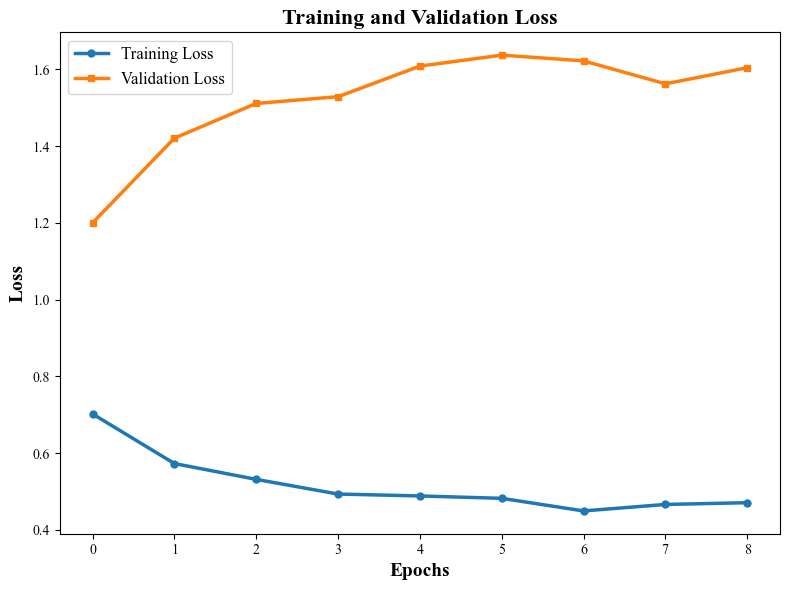

In [14]:
import matplotlib.pyplot as plt

# Set Times New Roman font
plt.rcParams['font.family'] = 'Times New Roman'

train_loss = history1.history['loss']
val_loss = history1.history['val_loss']

plt.figure(figsize=(8,6))

plt.plot(train_loss, marker='o', markersize=5, linewidth=2.5)
plt.plot(val_loss, marker='s', markersize=5, linewidth=2.5)

plt.title('Training and Validation Loss', fontsize=16, fontweight='bold')
plt.xlabel('Epochs', fontsize=14, fontweight='bold')
plt.ylabel('Loss', fontsize=14, fontweight='bold')

plt.legend(['Training Loss', 'Validation Loss'], fontsize=12)

plt.grid(False)
plt.tight_layout()

plt.savefig("loss_plot.tiff", dpi=300)
plt.show()

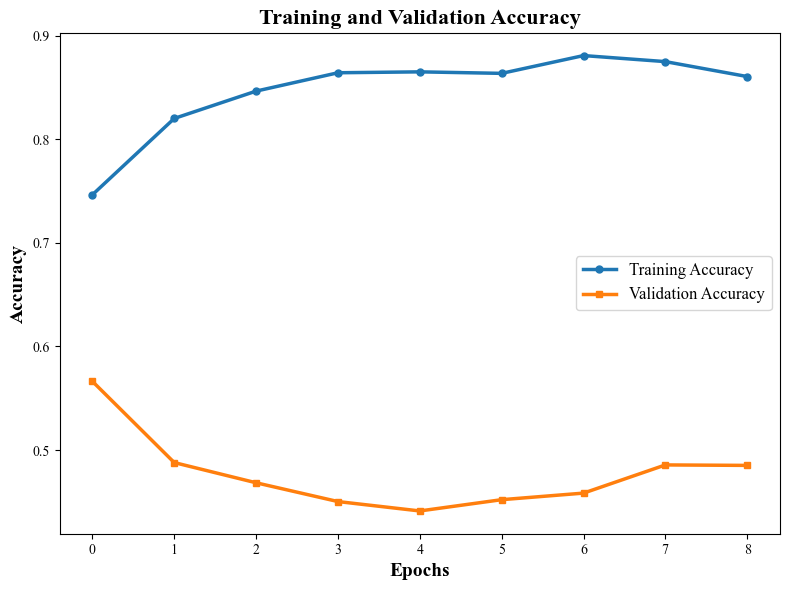

In [15]:
train_acc = history1.history['accuracy']
val_acc = history1.history['val_accuracy']

plt.figure(figsize=(8,6))

plt.plot(train_acc, marker='o', markersize=5, linewidth=2.5)
plt.plot(val_acc, marker='s', markersize=5, linewidth=2.5)

plt.title('Training and Validation Accuracy', fontsize=16, fontweight='bold')
plt.xlabel('Epochs', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy', fontsize=14, fontweight='bold')

plt.legend(['Training Accuracy', 'Validation Accuracy'], fontsize=12)

plt.grid(False)
plt.tight_layout()

plt.savefig("accuracy_plot.tiff", dpi=300)
plt.show()

In [ ]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt

# -------------------------------
# Get last conv layer
# -------------------------------
def get_last_conv_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name

last_conv_layer_name = get_last_conv_layer(model)

# -------------------------------
# Grad-CAM function
# -------------------------------
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        loss = predictions[:, pred_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    return heatmap.numpy()

In [ ]:
def display_gradcam(img_path, model, last_conv_layer_name):
    
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224,224))
    img_array = np.expand_dims(img/255.0, axis=0)

    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

    heatmap = cv2.resize(heatmap, (224,224))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

    return img, superimposed_img

In [ ]:
plt.rcParams['font.family'] = 'Times New Roman'

# Example images (replace with your dataset paths)
image_paths = [
    r"D:\test\healthy1.jpg",
    r"D:\test\initial1.jpg",
    r"D:\test\severe1.jpg"
]

titles = ['(a) Healthy', '(b) Initial Stage', '(c) Severe Stage']

fig, axes = plt.subplots(1, 3, figsize=(12,4))

for i, img_path in enumerate(image_paths):
    original, gradcam = display_gradcam(img_path, model, last_conv_layer_name)
    
    axes[i].imshow(cv2.cvtColor(gradcam, cv2.COLOR_BGR2RGB))
    axes[i].set_title(titles[i], fontsize=12, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.savefig("Fig_GradCAM.tiff", dpi=300)
plt.show()

In [16]:
import pickle

with open(r"D:\Chilli final dataset\Hybridcnnchilli_history.pkl", "wb") as f:
    pickle.dump(history1.history, f)

In [ ]:
with open(r"D:\Chilli final dataset\Hybridcnnchilli_history.pkl", "rb") as f:
    history = pickle.load(f)